# Features analysis code

## Requirements

In [41]:
 !pip3 install pandas openpyxl scipy numpy statsmodels matplotlib seaborn sklearn

## Imports

In [42]:
import pandas as pd
import openpyxl
import scipy
import numpy as np
from statsmodels.stats.multitest import multipletests
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, roc_auc_score

## Dataframe import

In [19]:
features_df = pd.read_excel("../extracted_features/extracted_features_final.xlsx")
features_df

,participant_id,gender,age,condition,perceived_topic_intimacy,personal_discomfort,revealing_personal_information,activity_time,stroke_count,stroke_total_length,...,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,loudness_sma3_amean,loudness_sma3_stddevNorm,jitterLocal_sma3nz_amean,shimmerLocaldB_sma3nz_amean,HNRdBACF_sma3nz_amean,total_speech_time,speech_ratio
0,4,M,23,1,5,1.571,1.25,1209.19,464,32406.17,...,22.730339,0.206271,6.394100,0.720653,0.784576,0.052364,1.437832,0.721781,265.572000,0.219628
1,4,M,23,2,4,1.000,1.00,1118.29,311,31294.04,...,22.718616,0.196353,5.203865,0.788069,0.791739,0.045662,1.446904,0.573326,436.644000,0.390457
2,5,M,20,1,3,1.143,1.25,976.01,483,251620.84,...,25.529953,0.167680,4.161392,1.161250,0.698495,0.040078,1.207340,3.940016,441.841250,0.452702
3,5,M,20,2,4,2.429,2.00,1007.23,318,207701.98,...,26.459944,0.172920,5.268013,1.366651,0.710858,0.043603,1.250476,3.951181,538.496000,0.534631
4,6,F,27,1,4,1.143,1.00,849.10,115,29558.12,...,30.298620,0.264035,14.135735,0.593465,0.661590,0.043968,1.169680,4.194973,237.840000,0.280108
5,6,F,27,2,3,1.286,2.75,556.19,137,15112.46,...,30.457277,0.251553,13.270615,0.584809,0.619730,0.041284,1.134220,4.613741,160.780000,0.289074
6,7,F,21,1,1,1.000,1.75,679.11,157,32312.35,...,32.126938,0.183674,3.902401,0.933588,0.607276,0.040284,1.065604,7.012737,348.904000,0.513767
7,7,F,21,2,3,1.000,1.75,508.09,105,18139.80,...,32.114250,0.195904,4.463032,0.878542,0.591010,0.042389,1.115764,6.872468,263.025812,0.517676
8,9,M,26,1,4,1.714,2.00,796.32,106,149419.08,...,23.867699,0.158444,2.880827,0.736282,0.622273,0.036094,1.220165,3.156016,228.916000,0.287467
9,9,M,26,2,2,1.286,1.50,564.09,83,31562.58,...,24.051962,0.174025,3.338686,0.769878,0.652640,0.036670,1.237442,3.040056,154.428000,0.273765


## Demographics

In [20]:
# For the computation on demographics
participants_df = features_df.drop_duplicates("participant_id")

### Gender

In [21]:
gender_percent = participants_df["gender"].value_counts(normalize=True) * 100

print(gender_percent)

gender
F    52.0
M    48.0
Name: proportion, dtype: float64


### Age

In [22]:
age_mean = participants_df["age"].mean()
age_std = participants_df["age"].std()
age_min = participants_df["age"].min()
age_max = participants_df["age"].max()

print(f"Mean age = {age_mean:.2f}")
print(f"SD age = {age_std:.2f}")
print(f"Range = {age_min}–{age_max}")

Mean age = 24.52
SD age = 4.93
Range = 18–36


## Manipulation check

In [34]:
# Helper function
def paired_test(df, variable, alternative, alpha=0.05):
    
    df_paired = df.pivot(
        index="participant_id",
        columns="condition",
        values=variable
    )
    
    diff = df_paired[2] - df_paired[1]   # condition 2 minus condition 1

    mean_c1 = np.mean(df_paired[1])
    mean_c2 = np.mean(df_paired[2])
    mean_diff = np.mean(diff)
    sd_diff = np.std(diff, ddof=1)
    
    # Cohen's dz
    cohens_dz = mean_diff / sd_diff if sd_diff != 0 else np.nan

    # 95% CI for mean difference
    n = len(diff)
    se_diff = sd_diff / np.sqrt(n)
    t_crit = scipy.stats.t.ppf(0.975, df=n-1)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff
    
    # Normality test
    shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)
    
    print(f"\n=== {variable} ===")
    print(f"Mean C1 = {mean_c1:.3f}")
    print(f"Mean C2 = {mean_c2:.3f}")
    print(f"Mean difference (C2 - C1) = {mean_diff:.3f}")
    print(f"95% CI of difference = [{ci_low:.3f}, {ci_high:.3f}]")
    print(f"Cohen's dz = {cohens_dz:.3f}")
    print(f"Shapiro p = {shapiro_p:.4f}")
    
    if shapiro_p > alpha:
        print("Normality met → Paired t-test")
        stat, p = scipy.stats.ttest_rel(df_paired[2], df_paired[1], alternative=alternative)
    else:
        print("Normality violated → Wilcoxon test")
        stat, p = scipy.stats.wilcoxon(df_paired[2], df_paired[1], alternative=alternative)

    print(f"Test statistic = {stat:.3f}")
    print(f"p-value = {p:.4f}")
    
    if p < alpha:
        print(f"Conclusion: {variable} is significantly higher in Condition 2 than in Condition 1.")
    else:
        print(f"Conclusion: There is no statistically significant evidence that {variable} is higher in Condition 2 than in Condition 1.")

In [35]:
paired_test(features_df, "perceived_topic_intimacy", "greater")
paired_test(features_df, "personal_discomfort", "greater")
paired_test(features_df, "revealing_personal_information", "greater")


=== perceived_topic_intimacy ===
Mean C1 = 2.840
Mean C2 = 3.680
Mean difference (C2 - C1) = 0.840
95% CI of difference = [0.118, 1.562]
Cohen's dz = 0.480
Shapiro p = 0.0086
Normality violated → Wilcoxon test
Test statistic = 227.500
p-value = 0.0122
Conclusion: perceived_topic_intimacy is significantly higher in Condition 2 than in Condition 1.

=== personal_discomfort ===
Mean C1 = 1.257
Mean C2 = 1.903
Mean difference (C2 - C1) = 0.646
95% CI of difference = [0.329, 0.963]
Cohen's dz = 0.842
Shapiro p = 0.2384
Normality met → Paired t-test
Test statistic = 4.210
p-value = 0.0002
Conclusion: personal_discomfort is significantly higher in Condition 2 than in Condition 1.

=== revealing_personal_information ===
Mean C1 = 1.790
Mean C2 = 2.660
Mean difference (C2 - C1) = 0.870
95% CI of difference = [0.522, 1.218]
Cohen's dz = 1.033
Shapiro p = 0.0095
Normality violated → Wilcoxon test
Test statistic = 220.000
p-value = 0.0001
Conclusion: revealing_personal_information is significantl

### Interpretation

TODO

Test → “Is there statistical evidence?”

Effect size → “How big is the difference?” How many standard deviations the average participant changed between conditions.

Example:

dz = 1.0
→ The average participant shifted 1 SD between conditions.

dz = 0.5
→ Half a standard deviation shift.

dz = 0.2
→ Small shift.

## Statistics on behavioral features

In [27]:
# Helper function
def paired_test(df, variable, alternative="two-sided", alpha=0.05):

    df_paired = df.pivot(
        index="participant_id",
        columns="condition",
        values=variable
    )
    
    diff = df_paired[2] - df_paired[1]
    
    # Normality test
    shapiro_stat, shapiro_p = scipy.stats.shapiro(diff)
    
    # Effect size: Cohen's dz (always computed)
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    cohens_dz = mean_diff / std_diff if std_diff != 0 else np.nan
    
    if shapiro_p > alpha:
        test_used = "paired_t"
        stat, p = scipy.stats.ttest_rel(df_paired[2], df_paired[1], alternative=alternative)
        wilcoxon_r = np.nan
        
    else:
        test_used = "wilcoxon"
        stat, p = scipy.stats.wilcoxon(df_paired[2], df_paired[1], alternative=alternative)
        
        # Wilcoxon effect size r
        diff_nonzero = diff[diff != 0]
        n = len(diff_nonzero)
        mean_w = n * (n + 1) / 4
        sd_w = np.sqrt(n * (n + 1) * (2*n + 1) / 24)
        z = (stat - mean_w) / sd_w if sd_w != 0 else np.nan
        wilcoxon_r = z / np.sqrt(n) if n != 0 else np.nan
    
    return {"feature": variable,
            "shapiro_p": shapiro_p,
            "test_used": test_used,
            "statistic": stat,
            "p_value": p,
            "cohens_dz": cohens_dz,
            "wilcoxon_r": wilcoxon_r,
            "mean_diff_c2_minus_c1": mean_diff}

In [28]:
# Run test on all behavioral features
exclude_columns = ["participant_id", "condition", "gender", "age", "perceived_topic_intimacy", "personal_discomfort", "revealing_personal_information"]
feature_columns = [col for col in features_df.columns if col not in exclude_columns]

results = []

for feature in feature_columns:
    result = paired_test(features_df, feature, alternative="two-sided")
    results.append(result)

results_df = pd.DataFrame(results)

In [31]:
# Apply FDR Correction (False Discovery Rate, Benjamini–Hochberg)
reject, pvals_corrected, _, _ = multipletests(results_df["p_value"], alpha=0.05, method="fdr_bh")

results_df["p_fdr"] = pvals_corrected
results_df["significant_fdr"] = reject
results_df = results_df.sort_values("p_fdr")
results_df["direction"] = np.where(results_df["mean_diff_c2_minus_c1"] > 0, "higher_in_c2", "lower_in_c2")

results_df

,feature,shapiro_p,test_used,statistic,p_value,cohens_dz,wilcoxon_r,mean_diff_c2_minus_c1,p_fdr,significant_fdr,direction
2,stroke_total_length,1.289390e-03,wilcoxon,73.000000,0.014722,-0.354566,-0.481634,-12430.381200,0.220831,False,lower_in_c2
1,stroke_count,6.855939e-01,paired_t,-2.147701,0.042045,-0.429540,NaN,-32.200000,0.315340,False,lower_in_c2
5,F0semitoneFrom27.5Hz_sma3nz_amean,5.808691e-01,paired_t,-1.143551,0.264088,-0.228710,NaN,-0.164123,0.632656,False,lower_in_c2
4,stroke_std_length,3.220842e-08,wilcoxon,109.000000,0.156338,-0.251653,-0.287904,-410.066000,0.632656,False,lower_in_c2
6,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,9.472394e-01,paired_t,1.009087,0.322999,0.201817,NaN,0.003836,0.632656,False,higher_in_c2
14,speech_ratio,5.190343e-01,paired_t,0.978854,0.337417,0.195771,NaN,0.014722,0.632656,False,higher_in_c2
12,HNRdBACF_sma3nz_amean,5.028892e-02,paired_t,-1.336293,0.193986,-0.267259,NaN,-0.169769,0.632656,False,lower_in_c2
11,shimmerLocaldB_sma3nz_amean,6.695614e-01,paired_t,1.251666,0.222754,0.250333,NaN,0.014490,0.632656,False,higher_in_c2
13,total_speech_time,2.371679e-01,paired_t,0.806109,0.428095,0.161222,NaN,13.368982,0.642143,False,higher_in_c2
10,jitterLocal_sma3nz_amean,2.031857e-01,paired_t,0.811518,0.425044,0.162304,NaN,0.000875,0.642143,False,higher_in_c2


## ML classifier

Correlation matrix

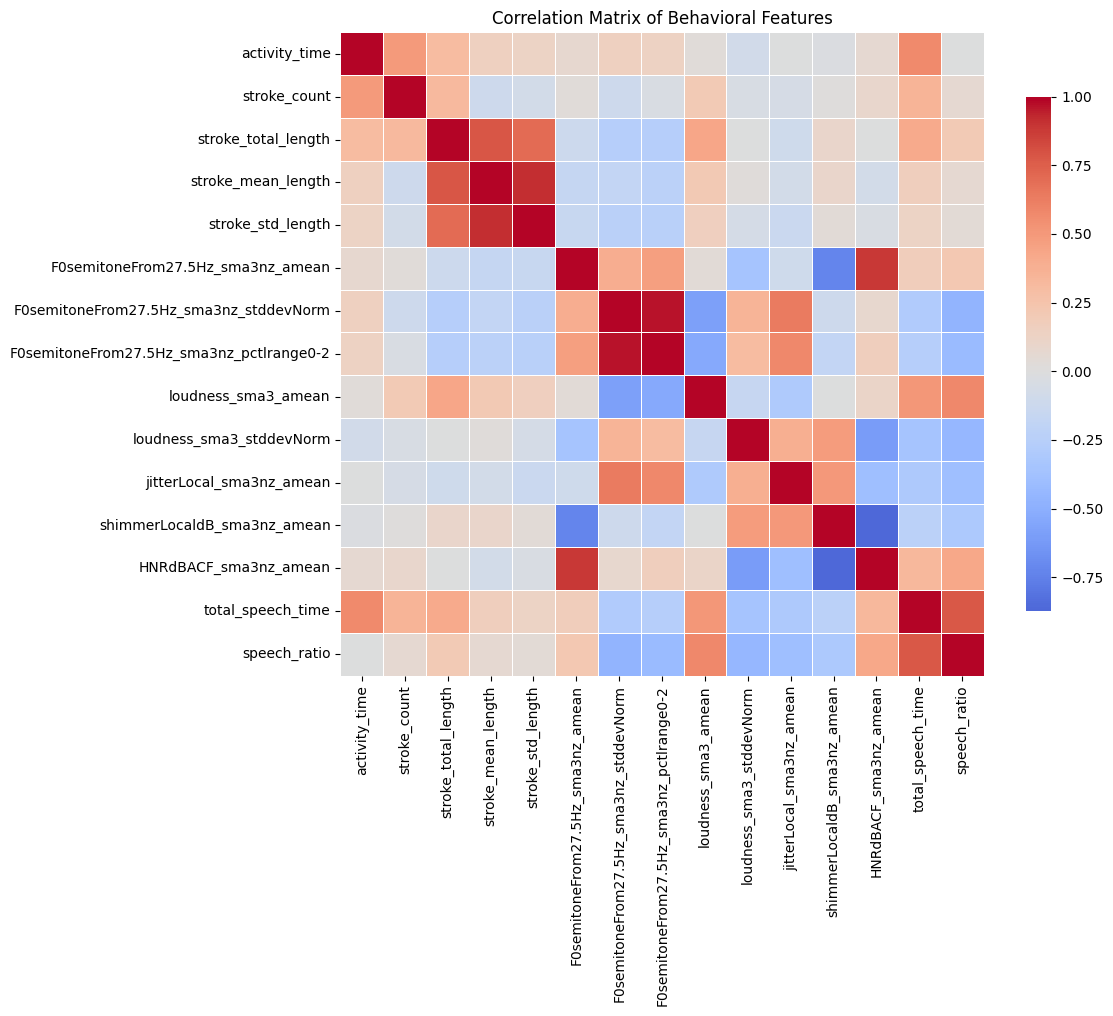

In [43]:
exclude_columns = ["participant_id", "condition", "gender", "age", "perceived_topic_intimacy", "personal_discomfort", "revealing_personal_information"]

# Select behavioral features only
behavioral_df = features_df.drop(columns=exclude_columns, errors="ignore")

corr_matrix = behavioral_df.corr(method="pearson")

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation Matrix of Behavioral Features")
plt.tight_layout()
plt.show()

In [44]:
# Find high correlations
high_corr_pairs = []

threshold = 0.85

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, value))

# Print results
print("\nHighly correlated feature pairs (|r| > 0.85):")
for pair in high_corr_pairs:
    print(f"{pair[0]}  <->  {pair[1]}  : r = {pair[2]:.3f}")


Highly correlated feature pairs (|r| > 0.85):
stroke_std_length  <->  stroke_mean_length  : r = 0.916
F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2  <->  F0semitoneFrom27.5Hz_sma3nz_stddevNorm  : r = 0.969
HNRdBACF_sma3nz_amean  <->  F0semitoneFrom27.5Hz_sma3nz_amean  : r = 0.888
HNRdBACF_sma3nz_amean  <->  shimmerLocaldB_sma3nz_amean  : r = -0.874


### Data standardization

Note: should be done separatly between train and test
Note: within subject -> data not independent -> Note: within subject -> Grouped cross-validation or Leave-one-subject-out (LOSO) (from sklearn.model_selection import GroupKFold)

LOSO: train on 24 participants and test on 1, repeated 25 times

In [ ]:
# Prepare data
X = features_df.drop(columns=exclude_columns, errors="ignore")
X = X.select_dtypes(include=[np.number]) # needed?

y = features_df["condition"]  # 1 or 2
y = (y == 2).astype(int) # Convert condition to 0/1

groups = features_df["participant_id"]

In [ ]:
# Setup Pipeline and standardizer
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=1000
    ))
])

In [ ]:
# Leave-One-Group-Out Cross Validation (LOGO CV)
# -> train on n-1 participants, test on 1 participant, repeat n times. Group = 1 participant with 2 conditions
logo = LeaveOneGroupOut()

y_true = []
y_pred = []
y_proba = []

for train_idx, test_idx in logo.split(X, y, groups):
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    pipeline.fit(X_train, y_train)
    
    preds = pipeline.predict(X_test)
    probas = pipeline.predict_proba(X_test)[:, 1]
    
    y_true.extend(y_test)
    y_pred.extend(preds)
    y_proba.extend(probas)

In [ ]:
Performance metrics
balanced_acc = balanced_accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_proba)

print("=== Cross-Validated Performance ===")
print(f"Balanced Accuracy: {balanced_acc:.3f}")
print(f"ROC-AUC: {roc_auc:.3f}")

In [ ]:
# Permutation test
score, perm_scores, pvalue = permutation_test_score(
    pipeline,
    X,
    y,
    groups=groups,
    cv=logo,
    scoring="balanced_accuracy",
    n_permutations=1000,
    n_jobs=-1
)

print("\n=== Permutation Test ===")
print(f"Observed Balanced Accuracy: {score:.3f}")
print(f"Permutation p-value: {pvalue:.4f}")

### Clasifier training and testing

### Principal component analysis